# PREDICTION & ANALYSIS OF PREMIER LEAGUE

# 1. Import libraries you will be using during the project

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 2. DATA MINING: Upload the data you will be using for the project, creat a data frame

In [2]:
##Upload documents
PremierLeague2526 = '..\Data\E0.csv'
#PremierLeague2526 = r"C:\Users\Sam\OneDrive\Escritorio\PROJECTS\Prediction_And_Analysis_Premier_League\E0.csv"

df_raw = pd.read_csv(PremierLeague2526)

#df_raw    #print DataFrame

In [3]:
#print(df_raw.shape)    #see lenth of data

In [4]:
#df_raw.head()     #show first 5 records

# 3. DATA CLEANING: identify the col you will need

- Create a list with the names of the columns you need, then creat a new DF and copy the columns you need from the DF_RAW

In [5]:
cols = ['Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR', 'HS', 'AS', 'HST', 'AST', 'HF', 'AF', 'HC', 'AC', 'HY', 'AY', 'HR', 'AR']
df = df_raw[cols].copy()

#df    #print df

- Clean data, delete duplicates, negatives, useless data

In [6]:
##DELETE NULLS

##Sum the null values on each column
#print(df.isnull().sum())

##Count rows with at least one null value
rows_with_nulls = df.isnull().any(axis=1).sum()
#print(f"\n Filas con valor nulo: {rows_with_nulls}")

##Delete records that have null records on any column
df = df.dropna()

df.shape

(380, 18)

In [7]:
##DELETE NEGATIVES

##Identify key columns
key_cols = ['FTHG', 'FTAG', 'HS', 'AS', 'HST', 'AST', 'HF', 'AF', 'HC', 'AC', 'HY', 'AY', 'HR', 'AR']

##Chceck for negative values 
negative_count = (df[key_cols] < 0).sum()
#print(negative_count)

##Delete records
df = df[(df[key_cols] >= 0).all(axis=1)]

In [8]:
##DELETE DUPLICATES

##Identify duplicates (all columns exactly the same)
duplicates = df.duplicated().sum()
print(duplicates)

##Verify duplicates based on key cols
key_cols_dup = ['Date', 'HomeTeam', 'AwayTeam']
duplicate_key = df.duplicated(subset=key_cols_dup).sum()
print(f"Partidos duplicados son: {duplicate_key}")

##Delete duplicated records
df = df.drop_duplicates()

0
Partidos duplicados son: 0


- Convert date

In [9]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')
df.head()

,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HS,AS,HST,AST,HF,AF,HC,AC,HY,AY,HR,AR
0,2025-08-15,Liverpool,Bournemouth,4,2,H,19,10,10,3,7,10,6,7,1,2,0,0
1,2025-08-16,Aston Villa,Newcastle,0,0,D,3,16,3,3,13,11,3,6,1,1,1,0
2,2025-08-16,Brighton,Fulham,1,1,D,10,7,4,2,16,15,4,3,3,3,0,0
3,2025-08-16,Sunderland,West Ham,3,0,H,10,12,5,4,8,10,5,7,0,1,0,0
4,2025-08-16,Tottenham,Burnley,3,0,H,16,14,6,4,14,8,6,5,0,0,0,0


- Verify logic ranges (difference from goals to high)

In [10]:
print(f"Goles local (FTHG) - Max: {df['FTHG'].max()}, Min: {df['FTHG'].min()}")
print(f"Goles visitante (FTAG) - Max: {df['FTAG'].max()}, Min: {df['FTAG'].min()}")

Goles local (FTHG) - Max: 5, Min: 0
Goles visitante (FTAG) - Max: 5, Min: 0


# 4. Data Exploration: Graphs

- Setup graph styles

In [11]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)    #Standard size of graphs

- GRAPH 1: Distribucion de Resultados

Text(0, 0.5, 'Number of Games')

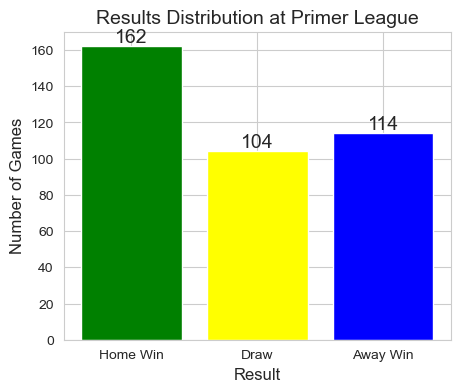

In [12]:
##Muestra cuantas veces gano, empato, perdio el local

##Contar cuantos partidos de cada tipo hay
results_g1 = df['FTR'].value_counts()
results_g1 = results_g1.reindex(['H', 'D', 'A'])

##Diccionario para nombres claros
names_g1 = {'H': 'Home Win', 'D': 'Draw', 'A': 'Away Win'}
plt.figure(figsize=(5,4))

##GRAPH
bars_g1 = plt.bar(
        [names_g1[x] for x in results_g1.index], 
        results_g1.values, 
        color=['green', 'yellow', 'blue']
    )

##Add numbers on top of bars
for bar in bars_g1:
    plt.text(     #Add text on top of each bar
        bar.get_x() + bar.get_width()/2,     #Calculates the possition on X
        bar.get_height() + 2, 
        int(bar.get_height()), 
        ha = 'center', 
        fontsize=14
    )
plt.title('Results Distribution at Primer League', fontsize=14)
plt.xlabel('Result', fontsize=12)
plt.ylabel('Number of Games', fontsize=12)

- GRAPH 2: Goal Distribution

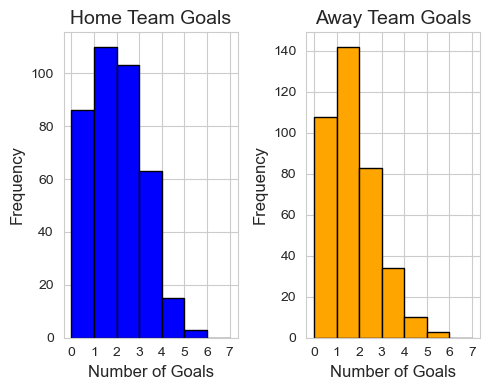

In [13]:
plt.figure(figsize=(5,4))

##GRAPH1
plt.subplot(1,2,1)

plt.hist(
    df['FTHG'], 
    bins=range(0, 8), 
    edgecolor='black', 
    #alpha=0.7, 
    color='blue'
)
plt.title('Home Team Goals', fontsize=14)
plt.xlabel('Number of Goals', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xticks(range(0,8))

##GRAPH2
plt.subplot(1,2,2)

plt.hist(
    df['FTAG'],
    bins=range(0,8),
    edgecolor='black',
    #alpha=0.7,
    color='orange'
)
plt.title("Away Team Goals", fontsize=14)
plt.xlabel("Number of Goals", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.xticks(range(0,8))

##Join
plt.tight_layout()

- GRAPH 3: Shots based on Result: Distribiution of shots when Home Team wins, draws or loses

C:\Users\Sam\AppData\Local\Temp\ipykernel_1556\2385504958.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='FTR', y='HS', data=df, palette={'H' : 'Green', 'D' : 'Yellow', 'A' : 'Blue'})


Text(0, 0.5, 'Number of Shots')

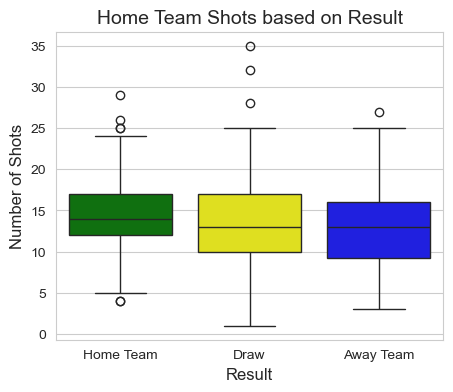

In [14]:
plt.figure(figsize=(5,4))
sns.boxplot(x='FTR', y='HS', data=df, palette={'H' : 'Green', 'D' : 'Yellow', 'A' : 'Blue'})

##Titles and Lables
plt.xticks([0,1,2],['Home Team', 'Draw', 'Away Team'])
plt.title('Home Team Shots based on Result', fontsize=14)
plt.xlabel('Result', fontsize=12)
plt.ylabel('Number of Shots', fontsize=12)

- GRAPH 4: Heat Map

Text(0.5, 1.0, 'Correlation Matrix - Game Stats')

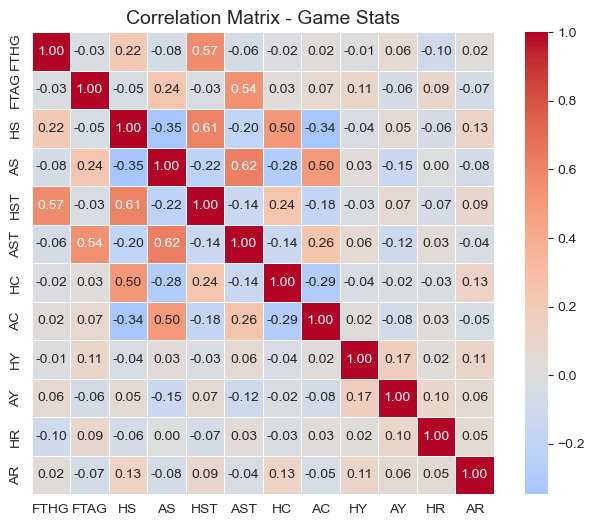

In [15]:
##Select Columns
cols = ['FTHG', 'FTAG', 'HS', 'AS', 'HST', 'AST', 'HC', 'AC', 'HY', 'AY', 'HR', 'AR']

##Calculate correlation
correlation = df[cols].corr()

##HEAT MAP
plt.figure(figsize=(8,6))
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0, fmt='.2f', square=True, linewidths=0.5)
plt.title('Correlation Matrix - Game Stats', fontsize=14)


- GRAPH 5: Bar Graph - Performance by Team

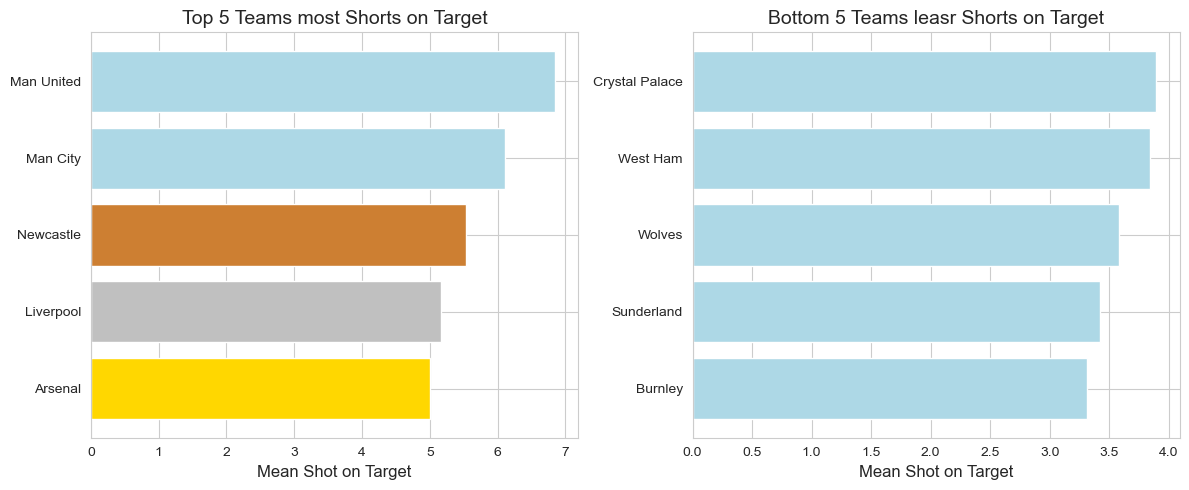

In [16]:
##Calculate the mean of Shots on Target by Home Team
mean_shots = df.groupby('HomeTeam')['HST'].mean().sort_values()

##Take top 5 and bottom 5
top5 = mean_shots.tail(5)
bottom5 = mean_shots.head(5)

plt.figure(figsize=(12,5))

##Top5
plt.subplot(1,2,1)
colors = ['gold', 'silver', '#cd7f32', 'lightblue', 'lightblue']
bars = plt.barh(top5.index, top5.values, color=colors)
plt.title('Top 5 Teams most Shorts on Target', fontsize=14)
plt.xlabel('Mean Shot on Target', fontsize=12)

##Bottom5
plt.subplot(1,2,2)
bars = plt.barh(bottom5.index, bottom5.values, color='lightblue')
plt.title('Bottom 5 Teams leasr Shorts on Target', fontsize=14)
plt.xlabel('Mean Shot on Target', fontsize=12)

plt.tight_layout()

- GRAPH 6: Scatter Plot: Relation between total shots and shots on target

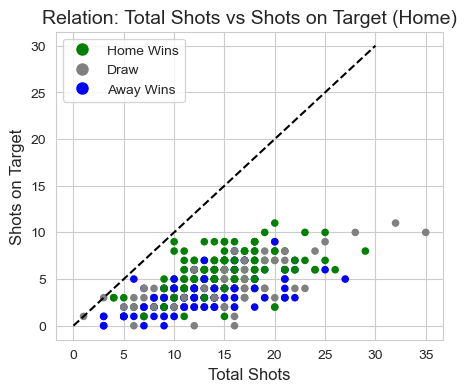

In [17]:
plt.figure(figsize=(5,4))

##Paint
result_colors = {'H': 'Green', 'D': 'Gray', 'A': 'Blue'}
graph_colors = df['FTR'].map(result_colors)

plt.scatter(df['HS'], df['HST'], c=graph_colors, s=20)
plt.plot([0, 30], [0, 30], 'k--', label='Reference Line') #Diagonal Line

plt.title('Relation: Total Shots vs Shots on Target (Home)', fontsize=14)
plt.xlabel("Total Shots", fontsize=12)
plt.ylabel("Shots on Target", fontsize=12)

plt.legend(
    handles=[
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='green', label='Home Wins', markersize=10),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', label='Draw', markersize=10),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='Blue', label='Away Wins', markersize=10)
    ]
)

- GRAPH 7: Lines Graph: Goal Tendency by date

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, '2025-08'),
  Text(1, 0, '2025-09'),
  Text(2, 0, '2025-10'),
  Text(3, 0, '2025-11'),
  Text(4, 0, '2025-12'),
  Text(5, 0, '2026-01'),
  Text(6, 0, '2026-02'),
  Text(7, 0, '2026-03'),
  Text(8, 0, '2026-04'),
  Text(9, 0, '2026-05')])

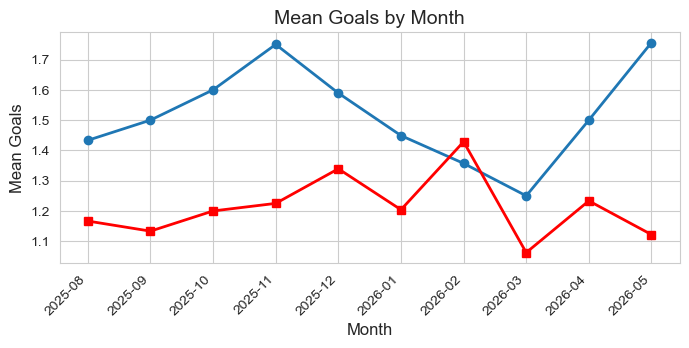

In [18]:
##Order by Date
df_date = df.sort_values('Date') 

##Create col by month
df_date['Month'] = df_date['Date'].dt.to_period('M')

##Mean of goals by month
goals_by_month = df_date.groupby('Month')[['FTHG','FTAG']].mean()

plt.figure(figsize = (8, 3))
plt.plot(goals_by_month.index.astype(str), goals_by_month['FTHG'], marker='o', label='Home Goals', linewidth=2)
plt.plot(goals_by_month.index.astype(str), goals_by_month['FTAG'], marker='s', label='Away Goals', linewidth=2, color='red')

plt.title('Mean Goals by Month', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Mean Goals', fontsize=12)
plt.xticks(rotation=45, ha='right')
#plt.legend() #
#plt.grid(True, alpha=0.3)
#plt.tight_layout()

# 5. Feature Engineering: Add new features

In [19]:
## Get extra features at the end like:
#shot_accuracy_local = HST/HS
df['shot_accuracy_home'] = df['HST'] / df['HS']
#shot_accuracy_away = AST/AS
df['shot_accuracy_away'] = df['AST'] / df['AS']
#Range of goal difference (values better for model)
df['shot_diff'] = df['HS'] - df['AS']
df['sot_diff'] = df['HST'] - df['AST']
df['corner_diff'] = df['HC'] - df['AC']
#corner_ratio = HC/(HC+AC)
#total_cards = HY + AY + HR + AR
#Avarege goals on the last 3 games

# 6. Predictive Modeling

### Logistic Regression

In [20]:
##Import Libraries
from sklearn.model_selection import train_test_split    #Function to split into Training Data and Testing Data
from sklearn.linear_model import LogisticRegression    #This is a classification Model despite the name
from sklearn.preprocessing import StandardScaler    #To scale data for model
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix    #Evaluation tools
                            #accuracy_score measures how many predictions where correct
                            #classification_report shows Precision Recall F1-score Support for each class
                            #confusion_matrix shows exactly where the model is making mistakes

features = [    #Can add shot_accuracy_local and shot_accuracy_away
    'HS', 'AS', 
    'HST', 'AST', 
    'HC', 'AC', 
    'HY', 'AY', 
    'HR', 'AR', 
    'shot_accuracy_home', 'shot_accuracy_away',
    'shot_diff', 'sot_diff', 'corner_diff'
]    

X = df[features]    #Information the model can use
y = df['FTR']    #What you want the model to learn -> answer (H, D, A)

X_train, X_test, y_train, y_test = train_test_split(    #X_train=features to learn, X_test=features used for evaluation, y_train=correct answers for training, y_test=correct answer for traininf
    X, 
    y, 
    test_size=0.2,    #20% test and 80% train
    random_state=42   #controls randomness, on every run it does same splits of the data
)

##lr = LogisticRegression(max_iter=1000)    #creates Logistic Regression object(nothing learned yet), during trainin model readjusts parameters
##lr.fit(X_train, y_train)    #Actual learning process

###TEST###
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
lr = LogisticRegression(max_iter=1000)    #creates Logistic Regression object(nothing learned yet), during trainin model readjusts parameters
lr.fit(X_train, y_train)
##########


y_pred_lr = lr.predict(X_test)    #Model sees new matches for predictions


###TEST###
cm = confusion_matrix(y_test, y_pred_lr)
print(cm)
#########

print(
    "Logistic Refression Accuracy: ", 
    accuracy_score(y_test, y_pred_lr)    #Compares y_test(actual result) against y_pred_lr(predicted result)
)

print(
    classification_report(
        y_test, 
        y_pred_lr)
)
#Precision=when model predicts Home Win, how often is it correct?
#Recall=of all actual Home Wins how many did the model find?
#F1-score=balance between precision and recall
#Support=number of examples in that class

[[11  4  6]
 [ 6  7  6]
 [ 4  1 31]]
Logistic Refression Accuracy:  0.6447368421052632
              precision    recall  f1-score   support

           A       0.52      0.52      0.52        21
           D       0.58      0.37      0.45        19
           H       0.72      0.86      0.78        36

    accuracy                           0.64        76
   macro avg       0.61      0.58      0.59        76
weighted avg       0.63      0.64      0.63        76



### Random Forest

In [21]:
#df.head()

In [22]:
#Import Libraries
from sklearn.model_selection import train_test_split    #To split data for training and testing
from sklearn.ensemble import RandomForestClassifier    #Model
#from sklearn.preprocessing import StandardScaler    #Scale data for Model NOT NEEDED FOR RANDOM FOREST
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix    #See how model is doing

#Select features and divide them into X and y
features_rf =[
    ##'FTHG', 'HTAG',
    'HS', 'AS',
    'HST', 'AST',
    'HY', 'AY',
    'HR', 'AR',
    'HC', 'AC',
    'shot_accuracy_home', 'shot_accuracy_away',
    'shot_diff', 'sot_diff', 'corner_diff'
]

X = df[features_rf]    #Training features
y = df['FTR']     #Result/Answer Expected

#Split data into test and training data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42
)

#Scale data
#scaler = StandardScaler()
#X_train = scaler.fit_transform(X_train)
#X_test = scaler.transform(X_test)

##MODELING AND PROCESSING 
#Create Model - DOESNT LEARN YET
rf = RandomForestClassifier(
    n_estimators = 300,
    random_state = 42,
    class_weight = 'balanced'
)
#Model actually starts learning
rf.fit(X_train, y_train)

#Trained model predicts results for the test matches
y_pred_rf = rf.predict(X_test)

#See results
print('Random Forest Accuracy: ', accuracy_score(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy:  0.5131578947368421
[[ 7  6  8]
 [ 8  5  6]
 [ 5  4 27]]
              precision    recall  f1-score   support

           A       0.35      0.33      0.34        21
           D       0.33      0.26      0.29        19
           H       0.66      0.75      0.70        36

    accuracy                           0.51        76
   macro avg       0.45      0.45      0.45        76
weighted avg       0.49      0.51      0.50        76



### Gradient Boosting

In [23]:
#Import Libraries
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

#Select columns for X and y
features_gb = [
    ##'FTHG', 'HTAG',
    'HS', 'AS',
    'HST', 'AST',
    'HY', 'AY',
    'HR', 'AR',
    'HC', 'AC',
    'shot_accuracy_home', 'shot_accuracy_away',
    'shot_diff', 'sot_diff', 'corner_diff'
]

X = df[features_gb]
y = df['FTR']

#Split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42
)

#Scale Numbers
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#Create Model 
gb = GradientBoostingClassifier(
    n_estimators = 100,
    learning_rate = 0.05,
    max_depth = 2,
    random_state = 42
)
#Actually train the model
gb.fit(X_train, y_train)

#Trained model predicts results for the test matches
y_pred_gb = gb.predict(X_test)


print('Gradient Boosting Accuracy: ', accuracy_score(y_test, y_pred_gb))
print(confusion_matrix(y_test, y_pred_gb))
print(classification_report(y_test, y_pred_gb))

Gradient Boosting Accuracy:  0.5394736842105263
[[ 8  8  5]
 [ 5  4 10]
 [ 4  3 29]]
              precision    recall  f1-score   support

           A       0.47      0.38      0.42        21
           D       0.27      0.21      0.24        19
           H       0.66      0.81      0.72        36

    accuracy                           0.54        76
   macro avg       0.47      0.47      0.46        76
weighted avg       0.51      0.54      0.52        76

